# R2：Dataset、DataLoader 与 Mini-batch

目标：使用 `TensorDataset` 和 `DataLoader` 将训练数据分成小批次，完成 mini-batch 梯度下降。

不要求：自己实现 Dataset 类或手推 batch 梯度。当前先理解数据如何流进训练循环。

## 为什么需要 mini-batch

上节每轮直接使用全部 100 个样本，称为 full-batch 训练。真实数据可能有几十万、几百万条，无法一次全部放入内存或 GPU。

mini-batch 每次只训练一小批样本，例如 16 条。一次完整遍历所有训练样本称为一个 epoch。

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
X = torch.linspace(-2, 2, 100).reshape(-1, 1)
y = 2 * X + 1 + 0.2 * torch.randn(100, 1)

## Dataset 和 DataLoader 分工

- `TensorDataset(X, y)`：把同一行的输入和标签绑成一个样本对。
- `DataLoader(...)`：决定每次取多少个样本、是否在每轮开始时打乱顺序。

这里 `batch_size=16`。100 个样本不能整除 16，因此最后一批只有 4 个样本，这是正常现象。

In [2]:
# 每条记录是 (X[i], y[i]) 这一对。
train_dataset = TensorDataset(X, y)

# shuffle=True：每个 epoch 开始时重新打乱样本顺序，避免模型总以固定顺序看到数据。
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print('训练样本数：', len(train_dataset))
print('每个 epoch 的 batch 数：', len(train_loader))

# 只查看一批，确认 DataLoader 提供的数据形状。
batch_X, batch_y = next(iter(train_loader))
print('一个 batch 的 X shape：', batch_X.shape)
print('一个 batch 的 y shape：', batch_y.shape)

训练样本数： 100
每个 epoch 的 batch 数： 7
一个 batch 的 X shape： torch.Size([16, 1])
一个 batch 的 y shape： torch.Size([16, 1])


## mini-batch 训练循环

关键变化只有一处：在每个 epoch 内，使用 `for batch_X, batch_y in train_loader` 依次取出小批数据训练。

每一个 batch 都会执行一次：清梯度 → 前向计算 → 损失 → 反向传播 → 更新。

In [3]:
model = nn.Linear(1, 1)
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

epochs = 100
epoch_loss_history = []

for epoch in range(epochs):
    batch_losses = []

    # DataLoader 在这里逐批提供数据。
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        prediction = model(batch_X)
        loss = loss_function(prediction, batch_y)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    # 一个 epoch 有多个 batch，因此记录这一轮所有 batch 损失的平均值。
    epoch_loss_history.append(sum(batch_losses) / len(batch_losses))

    if (epoch + 1) % 25 == 0:
        print(f'epoch {epoch + 1:>3}: mean batch loss = {epoch_loss_history[-1]:.4f}')

epoch  25: mean batch loss = 0.0403
epoch  50: mean batch loss = 0.0425
epoch  75: mean batch loss = 0.0372
epoch 100: mean batch loss = 0.0424



训练后参数：
weight 1.991
bias 1.01


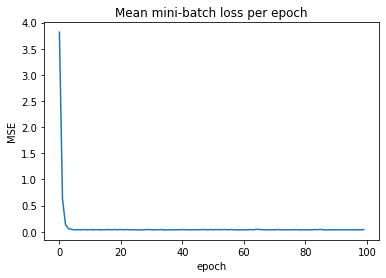

In [4]:
print('\n训练后参数：')
for name, parameter in model.named_parameters():
    print(name, round(parameter.detach().item(), 3))

plt.plot(epoch_loss_history)
plt.title('Mean mini-batch loss per epoch')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.show()

## 本节结论

DataLoader 不改变学习目标，只改变数据喂给模型的方式。训练循环的核心仍然不变。下一节会把数据划分为训练集和验证集，学习深度学习中如何监控泛化能力与保存最佳模型。